Handling Imbalance Dataset

When dealing with imbalanced datasets, where one class significantly outnumbers the other(s), it can lead to biased models that perform poorly on the minority class. Here are some strategies to handle imbalanced datasets:   
1. Upsampling: This involves increasing the number of samples in the minority class by duplicating existing samples or generating synthetic samples using techniques like SMOTE (Synthetic Minority Over-sampling Technique).
2. Downsampling: This involves reducing the number of samples in the majority class by randomly removing samples until the classes are balanced.

In [1]:
import numpy as np
import pandas as pd

# Setting a random seed for reproducibility
np.random.seed(123)

# Creating a datafrome with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [2]:
n_class_0, n_class_1

(900, 100)

In [3]:
# Creating my dataframe with imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class_0),
     'feature_2': np.random.normal(loc=0,scale=1,size=n_class_0), 
     'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class_1),
     'feature_2': np.random.normal(loc=0,scale=1,size=n_class_1), 
     'target': [1] * n_class_1
})

In [4]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [5]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [6]:
df.tail()

,feature_1,feature_2,target
995,-0.623629,0.845701,1
996,0.239810,-1.119923,1
997,-0.868240,-0.359297,1
998,0.902006,-1.609695,1
999,0.697490,0.013570,1


In [7]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [8]:
# Upsampling 

df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [9]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [10]:
df_minority_upsampled.shape

(900, 3)

In [11]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,-0.874146,-0.156083,1
992,0.196570,-0.602575,1
914,-0.067830,0.998053,1
971,0.272825,1.034197,1
960,0.870056,-0.449515,1


In [12]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [13]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [14]:
# Downsampling

# Randomly reduce majority class to match minority class size
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [15]:
# Check class balance after downsampling
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

### Explanation
- **Upsampling** duplicates (or synthetically creates) minority class samples until both classes are balanced.
- **Downsampling** removes majority class samples until both classes are balanced.
- Upsampling keeps all majority data but may increase overfitting risk.
- Downsampling is simple and fast but can discard useful information from the majority class.

### SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE creates new minority-class samples by interpolating between existing minority samples. Instead of duplicating rows, it generates synthetic points in feature space, which can help reduce overfitting compared to naive upsampling.

**When to use:**
- You want more minority examples without throwing away majority data.
- Features are numeric or can be meaningfully interpolated.


In [16]:
from sklearn.datasets import make_classification

In [17]:
X,y = make_classification(n_samples=1000, n_features=2, n_clusters_per_class=1, weights=[0.90],random_state=27, n_redundant=0)


In [18]:
import pandas as pd
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.899073,-2.352325,0
1,0.074282,-0.161025,0
2,0.258625,-0.840895,0
3,1.481190,-1.677339,0
4,-0.187633,0.681020,0


In [19]:
final_df['target'].value_counts()

target
0    898
1    102
Name: count, dtype: int64

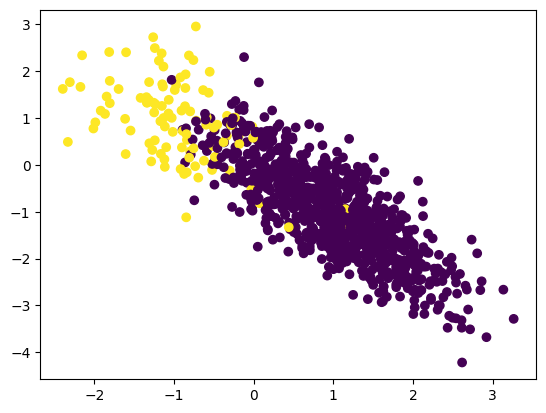

In [20]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
## transform the dataset using smote

oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [23]:
X.shape

(1796, 2)

In [24]:
y.shape

(1796,)

In [25]:
len(y[y==0])

898

In [26]:
len(y[y==1])

898

In [27]:
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.899073,-2.352325,0
1,0.074282,-0.161025,0
2,0.258625,-0.840895,0
3,1.481190,-1.677339,0
4,-0.187633,0.681020,0


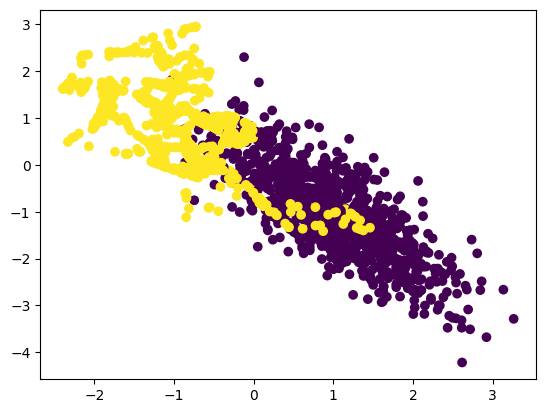

In [28]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

## Why accuracy is misleading on imbalanced data

The `df` built at the top of this notebook has a 900/100 class split. A model that **never even
looks at the features** and always predicts the majority class gets a high "accuracy" for free —
measured directly below, both by hand from the class counts and with
`sklearn.dummy.DummyClassifier(strategy="most_frequent")` as a real, fitted sanity check.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

counts = df['target'].value_counts()
majority_class = counts.idxmax()
naive_accuracy = counts.max() / counts.sum()
print(f"Class counts: {counts.to_dict()}")
print(f"Naive 'always predict class {majority_class}' accuracy (by hand): {naive_accuracy:.4f}")

X_imb, y_imb = df[['feature_1', 'feature_2']], df['target']
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train_imb, y_train_imb)
print(f"DummyClassifier(most_frequent) test accuracy: {accuracy_score(y_test_imb, dummy.predict(X_test_imb)):.4f}")
print("Both numbers agree: a model that memorizes nothing scores ~90% 'accuracy' here, "
      "while identifying zero minority-class cases — accuracy alone hides this completely.")


Class counts: {0: 900, 1: 100}
Naive 'always predict class 0' accuracy (by hand): 0.9000
DummyClassifier(most_frequent) test accuracy: 0.9000
Both numbers agree: a model that memorizes nothing scores ~90% 'accuracy' here, while identifying zero minority-class cases — accuracy alone hides this completely.


## From-scratch: what SMOTE's synthesis mechanism actually does

SMOTE's synthetic-sample rule, spelled out mechanically:

1. Pick a real minority-class point $p$.
2. Find its $k$ nearest neighbors — **among the minority class only** — using the same
   distance-based reasoning as `../../05-machine-learning/09-knn/notes.md` (Euclidean distance to
   every other minority point, sorted, closest $k$ kept).
3. Pick one of those $k$ neighbors at random, call it $q$.
4. Generate a synthetic point by linear interpolation: $p_{\text{synthetic}} = p + \lambda (q - p)$
   for a random $\lambda \in [0, 1]$ — a point somewhere on the line segment between $p$ and $q$,
   never exactly on top of either one.

This is the entire mechanism: SMOTE is nearest-neighbor search (exactly `09-knn`'s distance
computation and sort) plus a random interpolation step. No duplication of existing rows — every
synthetic point is a genuinely new coordinate, but constrained to lie *between* real minority
points, which is why it doesn't invent minority-class regions that don't already exist in the
data. The cell below implements exactly these four steps on a toy 2D minority class, with no call
to `imblearn`, and plots the real minority points against the synthetic ones it generates.

Real minority points: 102   Synthetic points generated: 50


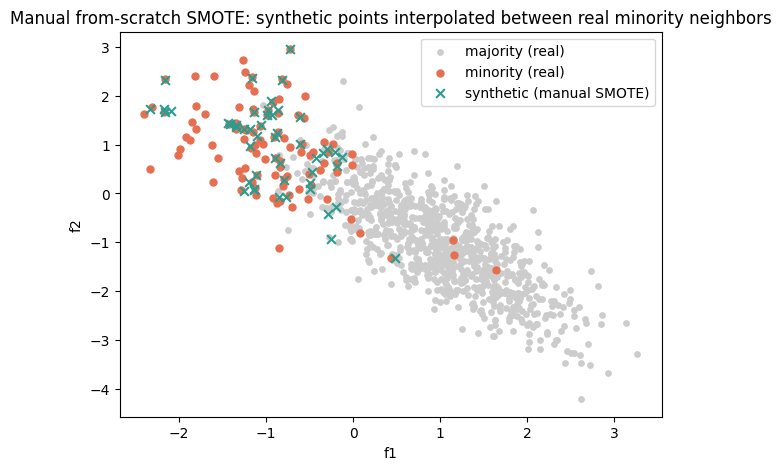

In [30]:
def manual_smote(minority_points: np.ndarray, k: int = 5, n_synthetic: int = 50, seed: int = 0) -> np.ndarray:
    """Generate synthetic minority-class points: pick a point, find its k nearest
    minority neighbors, interpolate between the point and a random one of those neighbors."""
    rng = np.random.default_rng(seed)
    n = len(minority_points)
    synthetic = []
    for _ in range(n_synthetic):
        i = rng.integers(0, n)
        p = minority_points[i]
        distances = np.linalg.norm(minority_points - p, axis=1)  # distance to every other minority point
        distances[i] = np.inf                                     # exclude itself
        nearest_k_idx = np.argsort(distances)[:k]                 # the k nearest minority neighbors
        j = rng.choice(nearest_k_idx)
        q = minority_points[j]
        lam = rng.random()
        synthetic.append(p + lam * (q - p))                       # interpolate between p and q
    return np.array(synthetic)


# Regenerate the ORIGINAL (pre-SMOTE) imbalanced toy set — `final_df` above was overwritten by
# imblearn's own SMOTE output, so we rebuild the untouched 898/102 imbalanced data here.
Xo, yo = make_classification(
    n_samples=1000, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=27, n_redundant=0
)
original_df = pd.concat([pd.DataFrame(Xo, columns=['f1', 'f2']), pd.DataFrame(yo, columns=['target'])], axis=1)

toy_minority = original_df[original_df['target'] == 1][['f1', 'f2']].to_numpy()
toy_majority = original_df[original_df['target'] == 0][['f1', 'f2']].to_numpy()
synthetic_points = manual_smote(toy_minority, k=5, n_synthetic=50, seed=0)

print(f"Real minority points: {toy_minority.shape[0]}   Synthetic points generated: {synthetic_points.shape[0]}")

plt.figure(figsize=(7, 5))
plt.scatter(toy_majority[:, 0], toy_majority[:, 1], c="#cccccc", s=15, label="majority (real)")
plt.scatter(toy_minority[:, 0], toy_minority[:, 1], c="#e76f51", s=25, label="minority (real)")
plt.scatter(synthetic_points[:, 0], synthetic_points[:, 1], c="#2a9d8f", marker="x", s=40, label="synthetic (manual SMOTE)")
plt.legend()
plt.title("Manual from-scratch SMOTE: synthetic points interpolated between real minority neighbors")
plt.xlabel("f1")
plt.ylabel("f2")
plt.show()


## Failure mode: applying SMOTE before the train/test split (data leakage)

Same category of bug as `../01-missing-values/notes.md`'s imputation-before-split failure mode,
here in a more damaging form: `SMOTE.fit_resample(X, y)` on the **whole** dataset, then splitting,
means some synthetic minority points end up in the training fold while being interpolated from
real minority points that end up in the *test* fold — so the training set contains points
manufactured directly from data the model is later "tested" on. The correct order is: split
first, fit `SMOTE` (and everything else) on the training fold only, leave the test fold as real,
untouched, still-imbalanced data. The cell below measures the difference on data with realistic
class overlap (imbalance alone barely moves the needle when classes are already this separable —
overlap is what makes the leak show up in the metric).

In [31]:
from sklearn.linear_model import LogisticRegression


def make_overlapping_df(seed, n_samples=80, ratio=0.85):
    """Two overlapping Gaussian classes (means 0.8 apart, both std=1) — harder than the
    well-separated `df`/`final_df` above, so leakage has a visible effect on the metric."""
    rng = np.random.default_rng(seed)
    n0 = int(n_samples * ratio)
    n1 = n_samples - n0
    c0 = pd.DataFrame({'f1': rng.normal(0, 1, n0), 'f2': rng.normal(0, 1, n0), 'target': [0] * n0})
    c1 = pd.DataFrame({'f1': rng.normal(0.8, 1, n1), 'f2': rng.normal(0.8, 1, n1), 'target': [1] * n1})
    return pd.concat([c0, c1]).reset_index(drop=True)


def leaky_smote_acc(data, seed):
    X, y = data[['f1', 'f2']], data['target']
    sm = SMOTE(random_state=0, k_neighbors=3)
    X_res, y_res = sm.fit_resample(X, y)  # LEAK: resampled BEFORE the split
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.4, random_state=seed, stratify=y_res)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))


def correct_smote_acc(data, seed):
    X, y = data[['f1', 'f2']], data['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)
    sm = SMOTE(random_state=0, k_neighbors=3)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)  # fit only on the TRAIN fold
    model = LogisticRegression(max_iter=1000).fit(X_train_res, y_train_res)
    return accuracy_score(y_test, model.predict(X_test))  # test fold stays real and imbalanced


leaky_accs, correct_accs = [], []
for trial in range(300):
    overlap_df = make_overlapping_df(trial)
    leaky_accs.append(leaky_smote_acc(overlap_df, trial))
    correct_accs.append(correct_smote_acc(overlap_df, trial))

wins_leaky = sum(a > b for a, b in zip(leaky_accs, correct_accs))
wins_correct = sum(a < b for a, b in zip(leaky_accs, correct_accs))
print(f"n=80, 85/15 imbalance, overlapping classes, 300 trials (test_size=0.4):")
print(f"  Leaky (SMOTE before split)   mean test accuracy: {np.mean(leaky_accs):.4f}")
print(f"  Correct (SMOTE after split)  mean test accuracy: {np.mean(correct_accs):.4f}")
print(f"  Mean difference (leaky - correct): {np.mean(leaky_accs) - np.mean(correct_accs):+.4f}")
print(f"  Trials where leaky > correct: {wins_leaky}/300   |   correct > leaky: {wins_correct}/300")


n=80, 85/15 imbalance, overlapping classes, 300 trials (test_size=0.4):
  Leaky (SMOTE before split)   mean test accuracy: 0.7338
  Correct (SMOTE after split)  mean test accuracy: 0.7125
  Mean difference (leaky - correct): +0.0213
  Trials where leaky > correct: 181/300   |   correct > leaky: 119/300


## Class weighting vs. resampling

Resampling (SMOTE, upsampling, downsampling) changes the *data* the model trains on. An
alternative that changes zero rows of data: tell the model's loss function to penalize minority
misclassifications more — `LogisticRegression(class_weight="balanced")` (and the equivalent
option on most `sklearn` classifiers) automatically weights each class inversely proportional to
its frequency. This is real, executed below, not just described: same overlapping-class data,
three variants — unweighted, class-weighted, and SMOTE-resampled — compared on **recall for the
minority class**, the metric resampling/weighting is meant to improve (accuracy alone would hide
the difference, per the naive-majority-classifier result above).

In [32]:
from sklearn.metrics import recall_score

weight_df = make_overlapping_df(seed=0, n_samples=400)
Xw, yw = weight_df[['f1', 'f2']], weight_df['target']
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.3, random_state=0, stratify=yw)

model_unweighted = LogisticRegression(max_iter=1000).fit(Xw_train, yw_train)
model_weighted = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xw_train, yw_train)

sm_train = SMOTE(random_state=0)
Xw_res, yw_res = sm_train.fit_resample(Xw_train, yw_train)  # correct order: resample train fold only
model_smote = LogisticRegression(max_iter=1000).fit(Xw_res, yw_res)

for name, model in [
    ("unweighted", model_unweighted),
    ("class_weight='balanced'", model_weighted),
    ("SMOTE-resampled", model_smote),
]:
    pred = model.predict(Xw_test)
    print(f"{name:26s}  accuracy={accuracy_score(yw_test, pred):.4f}   minority-class recall={recall_score(yw_test, pred):.4f}")


unweighted                  accuracy=0.8500   minority-class recall=0.0556
class_weight='balanced'     accuracy=0.6833   minority-class recall=0.6111
SMOTE-resampled             accuracy=0.6750   minority-class recall=0.5556
